In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sarveshchhetri/ev-battery-failure-prediction-dataset-200k")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ev-battery-failure-prediction-dataset-200k' dataset.
Path to dataset files: /kaggle/input/ev-battery-failure-prediction-dataset-200k


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder

In [ ]:
import os


print(os.listdir(path))

['data_dictionary.csv', 'feature_descriptions.md', 'ev_battery_failure_dataset.csv']


In [ ]:
import pandas as pd
import os

df = pd.read_csv(os.path.join(path, 'ev_battery_failure_dataset.csv'))
df.head()

,vehicle_id,vehicle_brand,vehicle_model,vehicle_type,manufacturing_year,battery_manufacturer,battery_chemistry,battery_capacity_kwh,drive_type,odometer_km,...,sensor_fault_count,BMS_warning_count,abnormal_voltage_events,battery_stress_index,aging_score,thermal_health_score,charging_quality_score,driving_stress_score,predicted_remaining_life_cycles,battery_failure
0,EV100000,Nissan,Leaf,SUV,2019.0,CATL,LMO,82.54,RWD,98163.0,...,2.0,3.0,0.0,0.0,53.5,66.0,65.2,0.0,401.0,0
1,EV100001,Audi,e-tron,Sedan,2018.0,Samsung SDI,NaN,64.17,AWD,113600.0,...,0.0,3.0,0.0,51.0,38.8,67.8,46.3,40.9,1094.0,0
2,EV100002,Toyota,bZ4X,Van,2018.0,Guoxuan,NMC,90.92,RWD,242253.0,...,4.0,1.0,0.0,36.2,66.1,48.6,0.0,6.5,645.0,0
3,EV100003,Volkswagen,ID.3,Hatchback,2022.0,CATL,NMC,47.35,AWD,83700.0,...,0.0,3.0,1.0,23.4,32.5,58.2,NaN,NaN,867.0,0
4,EV100004,Tesla,Model X,Crossover,2015.0,BYD Battery,NMC,68.04,FWD,88784.0,...,3.0,2.0,1.0,51.2,45.4,51.0,NaN,100.0,1090.0,0


In [ ]:
df.shape

(200000, 70)

In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 70 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   vehicle_id                       200000 non-null  object 
 1   vehicle_brand                    193564 non-null  object 
 2   vehicle_model                    191796 non-null  object 
 3   vehicle_type                     193568 non-null  object 
 4   manufacturing_year               190171 non-null  float64
 5   battery_manufacturer             193812 non-null  object 
 6   battery_chemistry                192786 non-null  object 
 7   battery_capacity_kwh             193097 non-null  float64
 8   drive_type                       192732 non-null  object 
 9   odometer_km                      191334 non-null  float64
 10  vehicle_age_years                192317 non-null  float64
 11  fleet_or_private                 191050 non-null  object 
 12  ba

In [ ]:
df.columns

Index(['vehicle_id', 'vehicle_brand', 'vehicle_model', 'vehicle_type',
       'manufacturing_year', 'battery_manufacturer', 'battery_chemistry',
       'battery_capacity_kwh', 'drive_type', 'odometer_km',
       'vehicle_age_years', 'fleet_or_private', 'battery_serial',
       'cycle_count', 'battery_health_percent', 'state_of_charge',
       'depth_of_discharge', 'state_of_health', 'cell_voltage_avg',
       'cell_voltage_std', 'pack_voltage', 'cell_temperature_avg',
       'cell_temperature_max', 'internal_resistance', 'charge_efficiency',
       'discharge_efficiency', 'remaining_capacity', 'capacity_loss_percent',
       'charging_cycles_last_month', 'fast_charge_ratio', 'slow_charge_ratio',
       'average_charge_power_kw', 'average_charging_time',
       'overnight_charging_ratio', 'home_charging_ratio',
       'charging_interruptions', 'overcharge_events', 'average_speed',
       'average_trip_distance', 'aggressive_acceleration_score',
       'hard_braking_score', 'regenerative

In [ ]:
df.describe()

,manufacturing_year,battery_capacity_kwh,odometer_km,vehicle_age_years,cycle_count,battery_health_percent,state_of_charge,depth_of_discharge,state_of_health,cell_voltage_avg,...,sensor_fault_count,BMS_warning_count,abnormal_voltage_events,battery_stress_index,aging_score,thermal_health_score,charging_quality_score,driving_stress_score,predicted_remaining_life_cycles,battery_failure
count,190171.000000,193097.000000,191334.000000,192317.000000,192348.000000,191018.000000,190364.000000,191687.000000,190435.000000,190602.000000,...,190326.000000,190948.000000,192400.000000,192691.000000,191635.000000,193671.000000,192814.000000,193190.000000,191026.000000,200000.000000
mean,2019.501333,76.236405,102822.193327,6.495245,296.383934,87.381787,54.847079,38.290397,87.297020,3.288515,...,1.331032,2.024745,0.494595,35.179580,29.912538,63.538378,50.989061,40.948318,1859.485986,0.099605
std,2.873497,21.302330,87965.819977,2.878180,282.614453,12.540742,21.450372,12.754524,12.527256,0.246766,...,1.265969,1.579874,0.729369,21.789144,28.011328,13.764340,27.815242,29.848473,1834.356925,0.299473
min,2015.000000,25.000000,500.000000,1.370000,1.000000,21.420000,2.000000,5.000000,21.800000,2.048500,...,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000,0.000000,0.000000,0.000000,0.000000
25%,2017.000000,60.980000,36128.000000,4.000000,95.000000,80.990000,40.070000,29.600000,80.910000,3.106025,...,0.000000,1.000000,0.000000,19.300000,6.900000,53.900000,30.600000,15.500000,891.000000,0.000000
50%,2020.000000,75.350000,78919.000000,6.340000,218.000000,91.120000,54.940000,38.280000,91.050000,3.355800,...,1.000000,2.000000,0.000000,33.200000,22.600000,61.400000,53.500000,38.900000,1245.000000,0.000000
75%,2022.000000,89.990000,146010.750000,9.000000,412.000000,97.430000,69.780000,46.910000,97.330000,3.463900,...,2.000000,3.000000,1.000000,48.500000,45.100000,74.000000,72.800000,63.000000,3085.000000,0.000000
max,2024.000000,149.010000,450000.000000,11.550000,3369.000000,99.800000,100.000000,92.030000,100.000000,3.853000,...,10.000000,13.000000,7.000000,100.000000,100.000000,100.000000,100.000000,100.000000,15474.000000,1.000000


In [ ]:
df.describe(include='object')

,vehicle_id,vehicle_brand,vehicle_model,vehicle_type,battery_manufacturer,battery_chemistry,drive_type,fleet_or_private,battery_serial,terrain_type
count,200000,193564,191796,193568,193812,192786,192732,191050,200000,192873
unique,200000,20,55,6,9,5,3,2,199775,5
top,EV299983,Tesla,Model X,SUV,CATL,NMC,FWD,Private,BAT-97470367,Flat
freq,1,21840,5527,58202,42675,112993,86890,137463,2,67488


In [ ]:
df.isnull().sum()

,0
vehicle_id,0
vehicle_brand,6436
vehicle_model,8204
vehicle_type,6432
manufacturing_year,9829
...,...
thermal_health_score,6329
charging_quality_score,7186
driving_stress_score,6810
predicted_remaining_life_cycles,8974


In [ ]:
print(df['battery_failure'].value_counts())
print(df['battery_failure'].value_counts(normalize=True) * 100)

battery_failure
0    180079
1     19921
Name: count, dtype: int64
battery_failure
0    90.0395
1     9.9605
Name: proportion, dtype: float64


In [ ]:
candidate_features = [
    'battery_capacity_kwh', 'odometer_km', 'vehicle_age_years',
    'cycle_count', 'battery_health_percent', 'state_of_charge',
    'depth_of_discharge', 'state_of_health', 'cell_voltage_avg',
    'cell_voltage_std', 'pack_voltage', 'cell_temperature_avg',
    'cell_temperature_max', 'internal_resistance', 'charge_efficiency',
    'discharge_efficiency', 'remaining_capacity', 'capacity_loss_percent',
    'charging_cycles_last_month', 'fast_charge_ratio', 'overcharge_events',
    'aggressive_acceleration_score', 'hard_braking_score',
    'sensor_fault_count', 'BMS_warning_count'
]
target = 'battery_failure'

In [ ]:
df[candidate_features + [target]].isnull().sum().sort_values(ascending=False)

,0
fast_charge_ratio,9879
sensor_fault_count,9674
state_of_charge,9636
state_of_health,9565
capacity_loss_percent,9559
cell_temperature_max,9450
cell_voltage_avg,9398
charge_efficiency,9305
hard_braking_score,9239
BMS_warning_count,9052


In [ ]:
df_clean = df[candidate_features + [target]].copy()

for col in candidate_features:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [ ]:
df_clean[['cell_temperature_max', 'internal_resistance', 'cell_voltage_std']].describe()

,cell_temperature_max,internal_resistance,cell_voltage_std
count,200000.000000,200000.000000,200000.000000
mean,29.372443,0.547967,0.017412
std,14.198504,0.162884,0.007771
min,-46.998000,0.027660,0.001000
25%,20.770000,0.449500,0.011890
50%,29.160000,0.540900,0.016060
75%,37.560000,0.616300,0.021620
max,255.444000,4.478040,0.059190


In [ ]:
X = df_clean[candidate_features]
y = df_clean[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:

categorical_features = ['battery_chemistry', 'vehicle_brand', 'vehicle_type', 'drive_type', 'fleet_or_private', 'terrain_type']

for col in categorical_features:
    print(col, '->', df[col].nunique(), 'unique values')

battery_chemistry -> 5 unique values
vehicle_brand -> 20 unique values
vehicle_type -> 6 unique values
drive_type -> 3 unique values
fleet_or_private -> 2 unique values
terrain_type -> 5 unique values


In [ ]:
df_cat = df[categorical_features].copy()

for col in categorical_features:
    df_cat[col] = df_cat[col].fillna('Unknown')

In [ ]:
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# fit only on training rows to avoid leakage — so do this AFTER your train/test split,
# using the same row indices as X_train/X_test
cat_train = df_cat.loc[X_train.index]
cat_test = df_cat.loc[X_test.index]

encoded_train = encoder.fit_transform(cat_train)
encoded_test = encoder.transform(cat_test)

encoded_cols = encoder.get_feature_names_out(categorical_features)
encoded_train_df = pd.DataFrame(encoded_train, columns=encoded_cols, index=X_train.index)
encoded_test_df = pd.DataFrame(encoded_test, columns=encoded_cols, index=X_test.index)

In [ ]:
X_train_final = np.hstack([X_train_scaled, encoded_train_df.values])
X_test_final = np.hstack([X_test_scaled, encoded_test_df.values])

print(X_train_final.shape, X_test_final.shape)

(160000, 66) (40000, 66)


In [ ]:
n_healthy = (y_train == 0).sum()
n_failure = (y_train == 1).sum()
print(f"Healthy: {n_healthy}, Failure: {n_failure}, Ratio: {n_healthy / n_failure:.1f}:1")

Healthy: 144063, Failure: 15937, Ratio: 9.0:1


In [ ]:
print("Train failure rate:", y_train.mean())
print("Test failure rate:", y_test.mean())

Train failure rate: 0.09960625
Test failure rate: 0.0996


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(class_weight_dict)

{0: np.float64(0.5553126062903035), 1: np.float64(5.019765325971011)}


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

n_features = X_train_final.shape[1]

model = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc')
    ]
)

In [ ]:
history = model.fit(
    X_train_final, y_train,
    validation_split=0.2,
    epochs=300,
    batch_size=256,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/300
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - auc: 0.9624 - loss: 0.2455 - precision: 0.4361 - recall: 0.9307 - val_auc: 0.9806 - val_loss: 0.2166 - val_precision: 0.4912 - val_recall: 0.9709
Epoch 2/300
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - auc: 0.9754 - loss: 0.1916 - precision: 0.5031 - recall: 0.9484 - val_auc: 0.9813 - val_loss: 0.1929 - val_precision: 0.5206 - val_recall: 0.9626
Epoch 3/300
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - auc: 0.9769 - loss: 0.1851 - precision: 0.5158 - recall: 0.9513 - val_auc: 0.9817 - val_loss: 0.1942 - val_precision: 0.5158 - val_recall: 0.9648
Epoch 4/300
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - auc: 0.9782 - loss: 0.1796 - precision: 0.5231 - recall: 0.9521 - val_auc: 0.9819 - val_loss: 0.1898 - val_precision: 0.5237 - val_recall: 0.9632
Epoch 5/300
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - auc: 0.9787 - loss: 0.1778 - precision: 0.5234 - recall: 0.9539 - val_auc: 0.9820 - val_loss: 0.1924 - val_precision: 0.5296 - val_recall: 0.

In [ ]:
y_probs = model.predict(X_test_final).flatten()
print(y_probs[:10])

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
[0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 7.4496549e-01 5.3742105e-01 1.2063444e-07 0.0000000e+00]


In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

y_pred_default = (y_probs >= 0.5).astype(int)

print(classification_report(y_test, y_pred_default))
print("ROC-AUC:", roc_auc_score(y_test, y_probs))
print("PR-AUC:", average_precision_score(y_test, y_probs))

              precision    recall  f1-score   support

           0       0.99      0.92      0.95     36016
           1       0.56      0.93      0.70      3984

    accuracy                           0.92     40000
   macro avg       0.78      0.93      0.83     40000
weighted avg       0.95      0.92      0.93     40000

ROC-AUC: 0.9779398545704364
PR-AUC: 0.860636250168465


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for t in thresholds:
    preds = (y_probs >= t).astype(int)
    results.append({
        'threshold': round(t, 2),
        'precision': precision_score(y_test, preds, zero_division=0),
        'recall': recall_score(y_test, preds, zero_division=0),
        'f1': f1_score(y_test, preds, zero_division=0)
    })

pd.DataFrame(results)

,threshold,precision,recall,f1
0,0.10,0.474618,0.959839,0.635163
1,0.15,0.489583,0.955572,0.647449
2,0.20,0.501453,0.952811,0.657088
3,0.25,0.510736,0.949297,0.664150
4,0.30,0.520652,0.946034,0.671656
5,0.35,0.529262,0.942018,0.677743
6,0.40,0.542169,0.937500,0.687023
7,0.45,0.551867,0.934739,0.693999
8,0.50,0.563507,0.930974,0.702063
9,0.55,0.572270,0.926205,0.707439


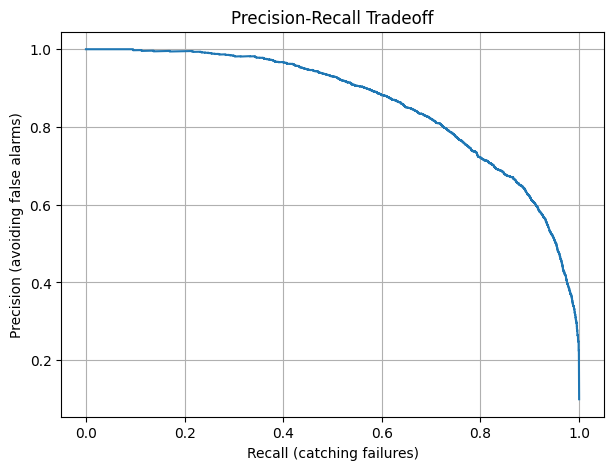

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precisions, recalls, pr_thresholds = precision_recall_curve(y_test, y_probs)

plt.figure(figsize=(7,5))
plt.plot(recalls, precisions)
plt.xlabel('Recall (catching failures)')
plt.ylabel('Precision (avoiding false alarms)')
plt.title('Precision-Recall Tradeoff')
plt.grid(True)
plt.show()

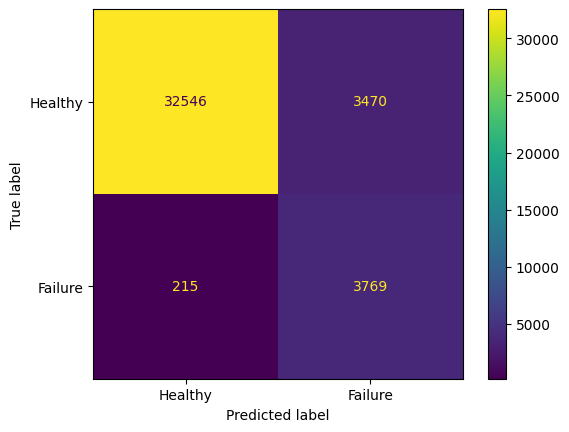

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

chosen_threshold = 0.3  # replace with whatever you pick from Cell 22's table
y_pred_chosen = (y_probs >= chosen_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_chosen)
ConfusionMatrixDisplay(cm, display_labels=['Healthy', 'Failure']).plot()
plt.show()

In [ ]:
precisions, recalls, pr_thresholds = precision_recall_curve(y_test, y_probs)  # y_probs, NOT y_pred_default

In [ ]:
print(len(precisions), len(recalls))

17873 17873


In [ ]:
comparison = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_pred_chosen,
    'predicted_probability': y_probs
})
comparison.head(20)

,actual,predicted,predicted_probability
0,0,0,0.000000e+00
1,0,0,0.000000e+00
2,0,0,0.000000e+00
3,0,0,0.000000e+00
4,0,0,0.000000e+00
5,0,0,0.000000e+00
6,1,1,7.449655e-01
7,0,1,5.374210e-01
8,0,0,1.206344e-07
9,0,0,0.000000e+00


In [ ]:
missed_failures = comparison[(comparison['actual'] == 1) & (comparison['predicted'] == 0)]
false_alarms = comparison[(comparison['actual'] == 0) & (comparison['predicted'] == 1)]

print(f"Missed failures: {len(missed_failures)}")
print(f"False alarms: {len(false_alarms)}")

missed_failures.sort_values('predicted_probability').head(10)

Missed failures: 215
False alarms: 3470


,actual,predicted,predicted_probability
7220,1,0,0.000000e+00
15157,1,0,0.000000e+00
14119,1,0,1.915106e-37
6393,1,0,9.405759e-36
17625,1,0,1.271646e-27
27458,1,0,4.400060e-27
9820,1,0,6.500710e-27
39726,1,0,1.074701e-26
6764,1,0,2.031676e-25
21658,1,0,2.140974e-23


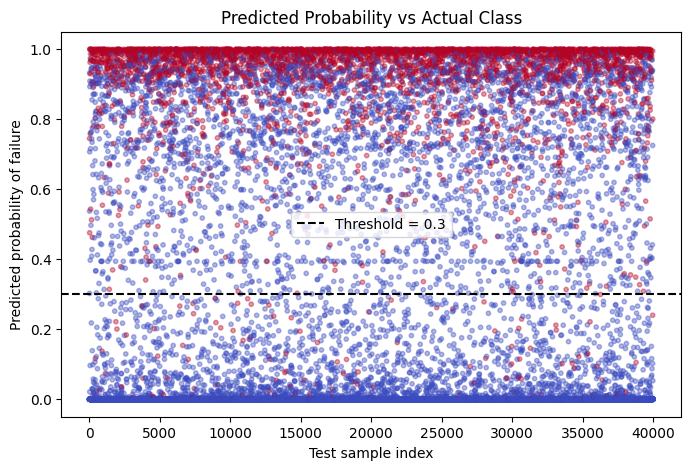

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(range(len(y_test)), y_probs, c=y_test, cmap='coolwarm', alpha=0.4, s=10)
plt.axhline(chosen_threshold, color='black', linestyle='--', label=f'Threshold = {chosen_threshold}')
plt.xlabel('Test sample index')
plt.ylabel('Predicted probability of failure')
plt.legend()
plt.title('Predicted Probability vs Actual Class')
plt.show()

In [ ]:
worst_misses_idx = missed_failures.sort_values('predicted_probability').head(10).index
X_test.iloc[worst_misses_idx]

,battery_capacity_kwh,odometer_km,vehicle_age_years,cycle_count,battery_health_percent,state_of_charge,depth_of_discharge,state_of_health,cell_voltage_avg,cell_voltage_std,...,discharge_efficiency,remaining_capacity,capacity_loss_percent,charging_cycles_last_month,fast_charge_ratio,overcharge_events,aggressive_acceleration_score,hard_braking_score,sensor_fault_count,BMS_warning_count
124844,101.53,210806.0,6.34,330.0,85.84,40.22,49.93,85.20,2.9300,0.01977,...,96.21,87.16,14.16,10.0,0.303,0.0,39.0,14.7,1.0,2.0
163714,90.49,118539.0,8.07,230.0,86.94,96.30,24.71,86.89,3.6525,0.02307,...,87.66,78.67,13.06,3.0,0.311,0.0,0.0,0.0,2.0,3.0
136639,66.53,12066.0,3.18,85.0,88.79,81.35,10.20,89.58,3.5532,0.01968,...,91.85,59.07,11.21,1.0,0.563,2.0,32.7,0.8,0.0,2.0
195170,49.03,49636.0,5.07,155.0,86.12,68.13,38.99,86.32,3.4964,0.02105,...,87.21,42.22,13.88,6.0,0.376,2.0,1.3,11.8,7.0,3.0
72603,122.15,209065.0,10.93,340.0,88.01,39.25,32.68,89.34,2.9454,0.02042,...,96.79,107.50,11.99,1.0,0.244,0.0,45.9,31.8,5.0,4.0
5878,86.16,161996.0,6.95,218.0,90.27,54.55,34.23,90.91,3.0074,0.02215,...,95.61,77.77,9.73,6.0,0.384,1.0,43.2,27.4,1.0,4.0
115896,123.90,265428.0,11.20,430.0,83.25,44.60,27.55,84.66,3.3855,0.03525,...,94.64,103.15,16.75,4.0,0.149,0.0,0.0,0.0,0.0,2.0
116704,51.09,41206.0,2.26,222.0,79.41,32.85,36.28,91.05,3.2470,0.01606,...,91.19,40.57,20.59,14.0,0.718,1.0,39.0,24.4,1.0,4.0
88989,88.99,70143.0,4.79,147.0,78.90,79.36,69.32,77.89,3.7051,0.02020,...,90.17,70.21,21.10,6.0,0.506,0.0,44.4,30.6,0.0,0.0
22312,81.84,106641.0,5.14,263.0,86.64,5.35,44.96,83.99,3.1856,0.02180,...,94.40,70.91,13.36,4.0,0.489,2.0,32.7,33.2,1.0,7.0


In [ ]:
worst_misses_idx = missed_failures.sort_values('predicted_probability').head(10).index
worst_miss_features = X_test.iloc[worst_misses_idx]

comparison_table = pd.DataFrame({
    'worst_miss_mean': worst_miss_features.mean(),
    'population_mean': X_train.mean(),
    'population_std': X_train.std()
})
comparison_table['z_score'] = (comparison_table['worst_miss_mean'] - comparison_table['population_mean']) / comparison_table['population_std']
comparison_table.sort_values('z_score', key=abs, ascending=False)

,worst_miss_mean,population_mean,population_std,z_score
BMS_warning_count,3.100000,2.022194,1.544823,0.697689
cell_voltage_std,0.021945,0.017411,0.007771,0.583476
battery_capacity_kwh,86.171000,76.227209,20.921985,0.475280
hard_braking_score,17.470000,23.764071,15.761757,-0.399325
sensor_fault_count,1.800000,1.315981,1.237511,0.391123
cell_temperature_avg,26.375000,21.692750,12.371702,0.378464
fast_charge_ratio,0.404300,0.338604,0.178988,0.367041
aggressive_acceleration_score,27.820000,33.042607,17.614523,-0.296494
remaining_capacity,73.723000,67.193500,22.131726,0.295029
overcharge_events,0.800000,0.582669,0.800871,0.271368


In [ ]:
df_clean['charge_stress_index'] = (
    df_clean['fast_charge_ratio'] * df_clean['overcharge_events'] *
    df_clean['charging_cycles_last_month']
)
df_clean['usage_intensity'] = df_clean['state_of_charge'] * df_clean['depth_of_discharge']

candidate_features_v2 = candidate_features + ['charge_stress_index', 'usage_intensity']

In [ ]:
X2 = df_clean[candidate_features_v2]
y2 = df_clean[target]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

scaler2 = RobustScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

In [ ]:
model_v2 = keras.Sequential([
    layers.Input(shape=(X2_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model_v2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[keras.metrics.Precision(name='precision'), keras.metrics.Recall(name='recall'), keras.metrics.AUC(name='auc')]
)

class_weights2 = compute_class_weight('balanced', classes=np.array([0,1]), y=y2_train)
class_weight_dict2 = {0: class_weights2[0], 1: class_weights2[1]}

history_v2 = model_v2.fit(
    X2_train_scaled, y2_train,
    validation_split=0.2, epochs=30, batch_size=256,
    class_weight=class_weight_dict2, verbose=1
)

Epoch 1/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - auc: 0.9560 - loss: 0.2708 - precision: 0.4013 - recall: 0.9334 - val_auc: 0.9794 - val_loss: 0.2231 - val_precision: 0.4840 - val_recall: 0.9641
Epoch 2/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - auc: 0.9732 - loss: 0.2014 - precision: 0.4890 - recall: 0.9479 - val_auc: 0.9811 - val_loss: 0.1897 - val_precision: 0.5185 - val_recall: 0.9558
Epoch 3/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - auc: 0.9755 - loss: 0.1915 - precision: 0.5062 - recall: 0.9491 - val_auc: 0.9814 - val_loss: 0.2106 - val_precision: 0.5006 - val_recall: 0.9641
Epoch 4/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - auc: 0.9769 - loss: 0.1860 - precision: 0.5141 - recall: 0.9492 - val_auc: 0.9815 - val_loss: 0.1863 - val_precision: 0.5348 - val_recall: 0.9549
Epoch 5/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - auc: 0.9775 - loss: 0.1835 - precision: 0.5187 - recall: 0.9495 - val_auc: 0.9819 - val_loss: 0.1784 - val_precision: 0.5417 - val_recall: 0.9561

In [ ]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    scale_pos_weight=(y2_train == 0).sum() / (y2_train == 1).sum(),
    eval_metric='aucpr',
    random_state=42
)
xgb_model.fit(X2_train_scaled, y2_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
nn_v2_probs = model_v2.predict(X2_test_scaled).flatten()
xgb_probs = xgb_model.predict_proba(X2_test_scaled)[:, 1]

results_compare = pd.DataFrame({
    'actual': y2_test.values,
    'nn_v1_prob': y_probs,          # your original model's probabilities, from Cell 20
    'nn_v2_prob': nn_v2_probs,
    'xgb_prob': xgb_probs
}, index=y2_test.index)

# the original 106 missed failures' indices, from Cell 26
# Fix: ensure `comparison` retains original index
comparison = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred_chosen,
    'predicted_probability': y_probs
})
missed_failures = comparison[(comparison['actual'] == 1) & (comparison['predicted'] == 0)]
original_misses_idx = missed_failures.index

recovered_by_nn_v2 = results_compare.loc[original_misses_idx]['nn_v2_prob'] >= chosen_threshold
recovered_by_xgb = results_compare.loc[original_misses_idx]['xgb_prob'] >= chosen_threshold

print(f"Originally missed: {len(original_misses_idx)}")
print(f"Recovered by NN v2 (engineered features): {recovered_by_nn_v2.sum()}")
print(f"Recovered by XGBoost: {recovered_by_xgb.sum()}")

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Originally missed: 215
Recovered by NN v2 (engineered features): 141
Recovered by XGBoost: 97


In [ ]:
for name, probs in [('NN v1 (original)', y_probs), ('NN v2 (+features)', nn_v2_probs), ('XGBoost', xgb_probs)]:
    preds = (probs >= chosen_threshold).astype(int)
    print(f"\n--- {name} ---")
    print("Recall:", recall_score(y2_test, preds))
    print("Precision:", precision_score(y2_test, preds))
    print("PR-AUC:", average_precision_score(y2_test, probs))


--- NN v1 (original) ---
Recall: 0.9460341365461847
Precision: 0.5206520237601878
PR-AUC: 0.860636250168465

--- NN v2 (+features) ---
Recall: 0.9776606425702812
Precision: 0.4703538220021736
PR-AUC: 0.8768888464770919

--- XGBoost ---
Recall: 0.946285140562249
Precision: 0.5538416336124578
PR-AUC: 0.8713814329426798


In [ ]:
model_comparison_data = {
    'Model': ['NN v1 (original)', 'NN v2 (+features)', 'XGBoost'],
    'Recall': [0.9460, 0.9777, 0.9463],
    'Precision': [0.5207, 0.4704, 0.5538],
    'PR-AUC': [0.8606, 0.8769, 0.8714]
}
model_comparison_df = pd.DataFrame(model_comparison_data)
display(model_comparison_df)

,Model,Recall,Precision,PR-AUC
0,NN v1 (original),0.9460,0.5207,0.8606
1,NN v2 (+features),0.9777,0.4704,0.8769
2,XGBoost,0.9463,0.5538,0.8714


/tmp/ipykernel_4324/2963385468.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=model_comparison_df, ax=axes[i], palette='viridis')
/tmp/ipykernel_4324/2963385468.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=model_comparison_df, ax=axes[i], palette='viridis')
/tmp/ipykernel_4324/2963385468.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=model_comparison_df, ax=axes[i], palette='viridis')


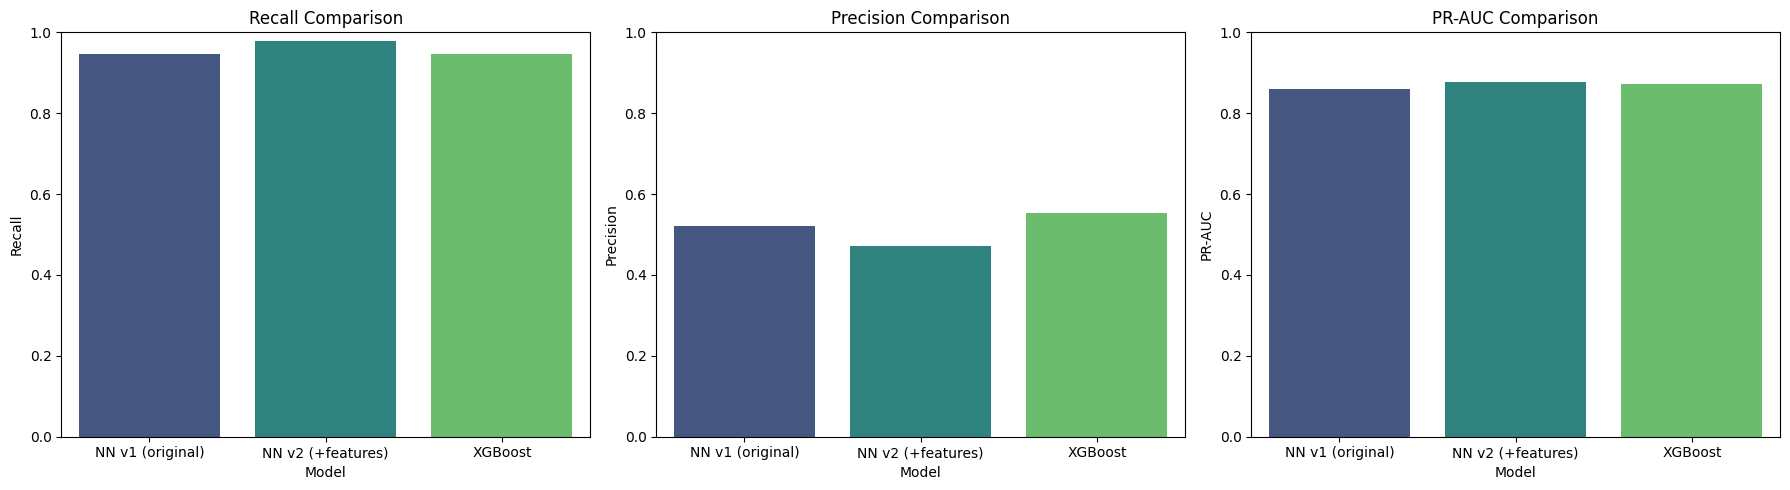

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics = ['Recall', 'Precision', 'PR-AUC']
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for i, metric in enumerate(metrics):
    sns.barplot(x='Model', y=metric, data=model_comparison_df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_ylabel(metric)
    axes[i].set_ylim(0, 1) # Metrics are between 0 and 1

plt.tight_layout()
plt.show()

Based on the PR-AUC (Precision-Recall Area Under the Curve), which is a robust metric for imbalanced datasets and considers both precision and recall, **NN v2 (+features)** is the best performing model. It shows a significantly higher recall while maintaining a good precision, making it effective at identifying most failures.

In [ ]:
import os

output_dir = '/mnt/user-data/outputs/'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Saving the model_v2 which has the best PR-AUC
model_v2_path = os.path.join(output_dir, 'voltrix_battery_model_v2.keras')
model_v2.save(model_v2_path)
print(f"'voltrix_battery_model_v2.keras' has been saved to '{model_v2_path}'.")

# List the contents of the output directory to confirm the file is there
print(os.listdir(output_dir))

'voltrix_battery_model_v2.keras' has been saved to '/mnt/user-data/outputs/voltrix_battery_model_v2.keras'.
['voltrix_battery_model_v2.keras']


In [ ]:
recovered_by_nn_v2 = results_compare.loc[original_misses_idx]['nn_v2_prob'] >= chosen_threshold
recovered_by_xgb = results_compare.loc[original_misses_idx]['xgb_prob'] >= chosen_threshold

print(f"Originally missed: {len(original_misses_idx)}")
print(f"Recovered by NN v2 (engineered features): {recovered_by_nn_v2.sum()}")
print(f"Recovered by XGBoost: {recovered_by_xgb.sum()}")

Originally missed: 215
Recovered by NN v2 (engineered features): 141
Recovered by XGBoost: 97


In [ ]:
import os

output_dir = '/mnt/user-data/outputs/'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

model_v2.save(os.path.join(output_dir, 'voltrix_battery_model_v2.keras'))

In [ ]:
import os

output_dir = '/mnt/user-data/outputs/'

# List the contents of the output directory to confirm the file is there
print(os.listdir(output_dir))


['voltrix_battery_model_v2.keras']


In [ ]:
import os

output_dir = '/mnt/user-data/outputs/'
model_filename = 'voltrix_battery_model_v2.keras'
model_path = os.path.join(output_dir, model_filename)

if os.path.exists(model_path):
    # Verify the file size to confirm it's a valid file
    file_size_bytes = os.path.getsize(model_path)
    print(f"Confirming: '{model_filename}' exists in '{output_dir}' with size {file_size_bytes} bytes.")
else:
    print(f"Error: '{model_filename}' not found in '{output_dir}'.")

# List contents of the output directory again
print("Contents of the output directory:", os.listdir(output_dir))

Confirming: 'voltrix_battery_model_v2.keras' exists in '/mnt/user-data/outputs/' with size 77361 bytes.
Contents of the output directory: ['voltrix_battery_model_v2.keras']


In [ ]:
from google.colab import files
import os

output_dir = '/mnt/user-data/outputs/'
model_filename = 'voltrix_battery_model_v2.keras'
model_path = os.path.join(output_dir, model_filename)

if os.path.exists(model_path):
    try:
        files.download(model_path)
        print(f"Successfully initiated download for '{model_filename}'.")
    except Exception as e:
        print(f"Error during download: {e}")
else:
    print(f"File '{model_filename}' not found at '{model_path}'. Cannot download.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Successfully initiated download for 'voltrix_battery_model_v2.keras'.


In [ ]:
from pathlib import Path

PROJECT = Path("voltrix")

folders = [
    PROJECT / "app",
    PROJECT / "static",
    PROJECT / "templates",
    PROJECT / "models",
    PROJECT / "training",
    PROJECT / "data",
]

for folder in folders:
    folder.mkdir(parents=True, exist_ok=True)

(PROJECT / "data" / ".gitkeep").touch()

print(f"Project created at: {PROJECT.resolve()}")

Project created at: /content/voltrix


In [ ]:
import os

BASE_DIR = "/content/Voltrix"

os.makedirs(BASE_DIR, exist_ok=True)

print("Voltrix folder:", BASE_DIR)
print("Contents:", os.listdir(BASE_DIR))

Voltrix folder: /content/Voltrix
Contents: []


In [ ]:
BASE_DIR = "/content/Voltrix"

In [ ]:
import os

os.makedirs("/content/Voltrix/static", exist_ok=True)

print("Folder structure created.")

Folder structure created.


In [ ]:
%%writefile /content/Voltrix/requirements.txt

fastapi
uvicorn[standard]
openai
python-dotenv
pydantic

Writing /content/Voltrix/requirements.txt


In [ ]:
%%writefile /content/Voltrix/.gitignore

.env
__pycache__/
*.pyc
.venv/
venv/
.ipynb_checkpoints/
.DS_Store

Writing /content/Voltrix/.gitignore


In [ ]:
%%writefile /content/Voltrix/.dockerignore

.git
.github
.env
__pycache__
*.pyc
.ipynb_checkpoints
venv
.venv

Writing /content/Voltrix/.dockerignore


In [ ]:
%%writefile /content/Voltrix/main.py

import os
from pathlib import Path

from dotenv import load_dotenv
from fastapi import FastAPI
from fastapi.staticfiles import StaticFiles
from fastapi.responses import FileResponse
from pydantic import BaseModel
from openai import OpenAI


# --------------------------------------------------
# LOAD ENVIRONMENT VARIABLES
# --------------------------------------------------

load_dotenv()

BASE_DIR = Path(__file__).resolve().parent

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

if not OPENAI_API_KEY:
    print("WARNING: OPENAI_API_KEY is not set.")


# --------------------------------------------------
# OPENAI CLIENT
# --------------------------------------------------

client = OpenAI(
    api_key=OPENAI_API_KEY
)


# --------------------------------------------------
# FASTAPI APPLICATION
# --------------------------------------------------

app = FastAPI(
    title="Voltrix API",
    description="Voltrix AI backend",
    version="1.0.0"
)


# --------------------------------------------------
# REQUEST MODEL
# --------------------------------------------------

class ChatRequest(BaseModel):
    message: str
    mode: str = "ask"


# --------------------------------------------------
# HEALTH CHECK
# --------------------------------------------------

@app.get("/health")
async def health():
    return {
        "status": "ok",
        "application": "Voltrix"
    }


# --------------------------------------------------
# CHAT ENDPOINT
# --------------------------------------------------

@app.post("/api/chat")
async def chat(request: ChatRequest):

    mode = request.mode

    if mode == "mcq":
        system_prompt = """
You are Voltrix, an AI study assistant for medical students.

Generate useful multiple-choice questions.

For each question:
1. Give the question.
2. Give four options: A, B, C and D.
3. State the correct answer.
4. Briefly explain why the answer is correct.

Keep the content educational and medically accurate.
"""

    elif mode == "flashcards":
        system_prompt = """
You are Voltrix, an AI study assistant for medical students.

Create useful medical flashcards.

Format them as:

Question:
...

Answer:
...

Keep answers concise but educational.
"""

    else:
        system_prompt = """
You are Voltrix, an AI study assistant designed to help medical students.

Answer questions clearly and accurately.

When appropriate:
- explain difficult concepts simply
- use headings
- use bullet points
- provide examples
- distinguish important facts
- avoid unnecessary repetition

If you are uncertain about a medical fact, say so rather than inventing information.
"""


    # --------------------------------------------------
    # CALL AI MODEL
    # --------------------------------------------------

    response = client.responses.create(
        model="gpt-4.1-mini",
        instructions=system_prompt,
        input=request.message
    )

    answer = response.output_text

    return {
        "answer": answer,
        "mode": mode
    }


# --------------------------------------------------
# SERVE FRONTEND
# --------------------------------------------------

app.mount(
    "/static",
    StaticFiles(directory=BASE_DIR / "static"),
    name="static"
)


@app.get("/")
async def home():
    return FileResponse(
        BASE_DIR / "static" / "index.html"
    )

Overwriting /content/Voltrix/main.py


In [ ]:
%%writefile /content/Voltrix/static/index.html

<!DOCTYPE html>
<html lang="en">

<head>

    <meta charset="UTF-8">

    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>Voltrix AI</title>

    <link rel="stylesheet" href="/static/style.css">

</head>

<body>

    <div class="app">

        <!-- SIDEBAR -->

        <aside class="sidebar">

            <div class="logo">
                <span class="logo-icon">V</span>
                <span>Voltrix</span>
            </div>

            <p class="tagline">
                AI study assistant for medical students.
            </p>

            <div class="sidebar-section">

                <p class="section-title">
                    Study Mode
                </p>

                <button
                    class="mode-button active"
                    data-mode="ask"
                >
                    💬 Ask Voltrix
                </button>

                <button
                    class="mode-button"
                    data-mode="mcq"
                >
                    📝 Generate MCQs
                </button>

                <button
                    class="mode-button"
                    data-mode="flashcards"
                >
                    🧠 Flashcards
                </button>

            </div>

        </aside>


        <!-- MAIN CONTENT -->

        <main class="main">

            <header class="header">

                <div>
                    <h1>Voltrix AI</h1>

                    <p>
                        Your intelligent medical study assistant
                    </p>
                </div>

                <div class="status">
                    <span class="status-dot"></span>
                    Online
                </div>

            </header>


            <!-- CHAT AREA -->

            <section
                id="chat-container"
                class="chat-container"
            >

                <div class="welcome">

                    <div class="welcome-icon">
                        V
                    </div>

                    <h2>
                        What would you like to study?
                    </h2>

                    <p>
                        Ask questions, generate MCQs,
                        or create flashcards.
                    </p>

                    <div class="suggestions">

                        <button class="suggestion">
                            Explain the cardiac cycle
                        </button>

                        <button class="suggestion">
                            Generate 5 MCQs on pharmacology
                        </button>

                        <button class="suggestion">
                            Create flashcards on glycolysis
                        </button>

                    </div>

                </div>

            </section>


            <!-- INPUT -->

            <div class="input-area">

                <div class="input-box">

                    <textarea
                        id="message"
                        placeholder="Ask Voltrix anything..."
                        rows="1"
                    ></textarea>

                    <button
                        id="send-button"
                        class="send-button"
                    >
                        ➤
                    </button>

                </div>

                <p class="disclaimer">
                    Voltrix is an educational tool and should not
                    replace professional medical advice.
                </p>

            </div>

        </main>

    </div>


    <script src="/static/app.js"></script>

</body>

</html>

Writing /content/Voltrix/static/index.html


In [ ]:
%%writefile /content/Voltrix/static/style.css

* {
    box-sizing: border-box;
    margin: 0;
    padding: 0;
}

body {
    font-family: Arial, Helvetica, sans-serif;
    background: #f7f8fc;
    color: #1f2937;
}

.app {
    display: flex;
    height: 100vh;
}


/* SIDEBAR */

.sidebar {
    width: 260px;
    background: #111827;
    color: white;
    padding: 28px 20px;
}

.logo {
    display: flex;
    align-items: center;
    gap: 10px;
    font-size: 24px;
    font-weight: bold;
}

.logo-icon {
    width: 38px;
    height: 38px;
    display: flex;
    align-items: center;
    justify-content: center;
    border-radius: 10px;
    background: #6366f1;
}

.tagline {
    margin-top: 15px;
    color: #9ca3af;
    line-height: 1.5;
}

.sidebar-section {
    margin-top: 45px;
}

.section-title {
    color: #9ca3af;
    font-size: 13px;
    margin-bottom: 12px;
    text-transform: uppercase;
}

.mode-button {
    display: block;
    width: 100%;
    border: none;
    background: transparent;
    color: #d1d5db;
    text-align: left;
    padding: 13px;
    margin-bottom: 8px;
    border-radius: 8px;
    cursor: pointer;
    font-size: 14px;
}

.mode-button:hover {
    background: #1f2937;
}

.mode-button.active {
    background: #6366f1;
    color: white;
}


/* MAIN */

.main {
    flex: 1;
    display: flex;
    flex-direction: column;
    min-width: 0;
}

.header {
    height: 80px;
    padding: 20px 35px;
    background: white;
    border-bottom: 1px solid #e5e7eb;
    display: flex;
    justify-content: space-between;
    align-items: center;
}

.header h1 {
    font-size: 20px;
}

.header p {
    color: #6b7280;
    margin-top: 4px;
    font-size: 14px;
}

.status {
    font-size: 14px;
    color: #4b5563;
}

.status-dot {
    display: inline-block;
    width: 8px;
    height: 8px;
    background: #22c55e;
    border-radius: 50%;
    margin-right: 6px;
}


/* CHAT */

.chat-container {
    flex: 1;
    overflow-y: auto;
    padding: 35px;
}

.welcome {
    max-width: 700px;
    margin: 60px auto;
    text-align: center;
}

.welcome-icon {
    width: 60px;
    height: 60px;
    margin: auto;
    display: flex;
    justify-content: center;
    align-items: center;
    background: #6366f1;
    color: white;
    font-size: 28px;
    font-weight: bold;
    border-radius: 16px;
}

.welcome h2 {
    margin-top: 20px;
    font-size: 25px;
}

.welcome p {
    color: #6b7280;
    margin-top: 10px;
}

.suggestions {
    margin-top: 30px;
    display: flex;
    flex-direction: column;
    gap: 10px;
}

.suggestion {
    border: 1px solid #e5e7eb;
    background: white;
    padding: 14px;
    border-radius: 10px;
    cursor: pointer;
    text-align: left;
}

.suggestion:hover {
    border-color: #6366f1;
}


/* MESSAGES */

.message {
    max-width: 800px;
    margin: 0 auto 20px auto;
    padding: 16px 20px;
    border-radius: 12px;
    line-height: 1.6;
    white-space: pre-wrap;
}

.message.user {
    background: #6366f1;
    color: white;
}

.message.assistant {
    background: white;
    border: 1px solid #e5e7eb;
}


/* INPUT */

.input-area {
    padding: 20px 35px;
    background: white;
    border-top: 1px solid #e5e7eb;
}

.input-box {
    max-width: 900px;
    margin: auto;
    display: flex;
    align-items: flex-end;
    gap: 10px;
    border: 1px solid #d1d5db;
    border-radius: 14px;
    padding: 10px;
    background: white;
}

textarea {
    flex: 1;
    resize: none;
    border: none;
    outline: none;
    font-size: 15px;
    padding: 8px;
    font-family: inherit;
}

.send-button {
    width: 42px;
    height: 42px;
    border: none;
    border-radius: 10px;
    background: #6366f1;
    color: white;
    cursor: pointer;
    font-size: 18px;
}

.send-button:hover {
    background: #4f46e5;
}

.disclaimer {
    text-align: center;
    color: #9ca3af;
    font-size: 11px;
    margin-top: 10px;
}


/* MOBILE */

@media (max-width: 700px) {

    .sidebar {
        display: none;
    }

    .header {
        padding: 15px 20px;
    }

    .chat-container {
        padding: 20px;
    }

    .input-area {
        padding: 15px;
    }

}

Writing /content/Voltrix/static/style.css


In [ ]:
%%writefile /content/Voltrix/static/app.js

let currentMode = "ask";


const messageInput = document.getElementById("message");
const sendButton = document.getElementById("send-button");
const chatContainer = document.getElementById("chat-container");

const modeButtons = document.querySelectorAll(".mode-button");
const suggestions = document.querySelectorAll(".suggestion");


// --------------------------------------------------
// CHANGE MODE
// --------------------------------------------------

modeButtons.forEach(button => {

    button.addEventListener("click", () => {

        modeButtons.forEach(btn => {
            btn.classList.remove("active");
        });

        button.classList.add("active");

        currentMode = button.dataset.mode;

        updatePlaceholder();

    });

});


// --------------------------------------------------
// UPDATE PLACEHOLDER
// --------------------------------------------------

function updatePlaceholder() {

    if (currentMode === "mcq") {

        messageInput.placeholder =
            "What topic should I generate MCQs about?";

    } else if (currentMode === "flashcards") {

        messageInput.placeholder =
            "What topic should I create flashcards about?";

    } else {

        messageInput.placeholder =
            "Ask Voltrix anything...";

    }

}


// --------------------------------------------------
// SUGGESTIONS
// --------------------------------------------------

suggestions.forEach(button => {

    button.addEventListener("click", () => {

        messageInput.value = button.textContent;

        sendMessage();

    });

});


// --------------------------------------------------
// SEND MESSAGE
// --------------------------------------------------

sendButton.addEventListener("click", sendMessage);


messageInput.addEventListener("keydown", event => {

    if (event.key === "Enter" && !event.shiftKey) {

        event.preventDefault();

        sendMessage();

    }

});


async function sendMessage() {

    const message = messageInput.value.trim();

    if (!message) {
        return;
    }


    // Remove welcome screen

    const welcome = document.querySelector(".welcome");

    if (welcome) {
        welcome.remove();
    }


    // Show user message

    addMessage(
        message,
        "user"
    );


    messageInput.value = "";

    sendButton.disabled = true;


    // Show loading

    const loading = addMessage(
        "Voltrix is thinking...",
        "assistant"
    );


    try {

        const response = await fetch(
            "/api/chat",
            {
                method: "POST",

                headers: {
                    "Content-Type": "application/json"
                },

                body: JSON.stringify({
                    message: message,
                    mode: currentMode
                })
            }
        );


        if (!response.ok) {

            throw new Error(
                "Server returned an error."
            );

        }


        const data = await response.json();


        loading.textContent = data.answer;


    } catch (error) {

        loading.textContent =
            "Sorry, something went wrong. Please try again.";

        console.error(error);

    }


    sendButton.disabled = false;

    messageInput.focus();

}


// --------------------------------------------------
// ADD MESSAGE TO CHAT
// --------------------------------------------------

function addMessage(text, sender) {

    const message = document.createElement("div");

    message.classList.add(
        "message",
        sender
    );

    message.textContent = text;

    chatContainer.appendChild(message);

    chatContainer.scrollTop =
        chatContainer.scrollHeight;

    return message;

}

Writing /content/Voltrix/static/app.js


In [ ]:
%%writefile /content/Voltrix/Dockerfile

FROM python:3.11-slim

WORKDIR /app

ENV PYTHONDONTWRITEBYTECODE=1
ENV PYTHONUNBUFFERED=1

COPY requirements.txt .

RUN pip install --no-cache-dir -r requirements.txt

COPY . .

EXPOSE 8000

CMD ["sh", "-c", "uvicorn main:app --host 0.0.0.0 --port ${PORT:-8000}"]

Writing /content/Voltrix/Dockerfile


In [ ]:
%%writefile /content/Voltrix/.env

OPENAI_API_KEY=PASTE_YOUR_OPENAI_API_KEY_HERE

Writing /content/Voltrix/.env


In [ ]:
import os

for root, dirs, files in os.walk("/content/Voltrix"):

    level = root.replace("/content/Voltrix", "").count(os.sep)

    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}    {file}")

Voltrix/
    .env
    main.py
    requirements.txt
    Dockerfile
    .gitignore
    .dockerignore
    static/
        index.html
        style.css
        app.js


In [ ]:
%cd /content/Voltrix

!pip install -q -r requirements.txt

/content/Voltrix


In [ ]:
!docker --version

/bin/bash: line 1: docker: command not found


In [ ]:
%cd /content/Voltrix

!docker build -t voltrix .

/content/Voltrix
/bin/bash: line 1: docker: command not found


In [ ]:
!docker run -d -p 8000:8000 --env-file .env --name voltrix-container voltrix

/bin/bash: line 1: docker: command not found


In [ ]:
!docker ps

/bin/bash: line 1: docker: command not found


In [ ]:
!docker stop voltrix-container
!docker rm voltrix-container

/bin/bash: line 1: docker: command not found
/bin/bash: line 1: docker: command not found


In [ ]:
%cd /content/Voltrix

!git init

/content/Voltrix
hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/Voltrix/.git/


In [ ]:
!git config --global user.name "Samuel333"
!git config --global user.email "scodes020@gmail.com"

In [ ]:
%cd /content/Voltrix

!git status

/content/Voltrix
On branch master

No commits yet

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.dockerignore
	.gitignore
	Dockerfile
	main.py
	requirements.txt
	static/

nothing added to commit but untracked files present (use "git add" to track)


In [ ]:
%cd /content/Voltrix

!git add .

/content/Voltrix


In [ ]:
!git commit -m "Initial Voltrix application"

[master (root-commit) 33b157e] Initial Voltrix application
 8 files changed, 865 insertions(+)
 create mode 100644 .dockerignore
 create mode 100644 .gitignore
 create mode 100644 Dockerfile
 create mode 100644 main.py
 create mode 100644 requirements.txt
 create mode 100644 static/app.js
 create mode 100644 static/index.html
 create mode 100644 static/style.css


In [ ]:
%cd /content/Voltrix

!git branch -M main

!git remote add origin https://github.com/Samuel333/voltrix.git

/content/Voltrix


In [ ]:
%cd /content/Voltrix

!git push -u origin main

/content/Voltrix
fatal: could not read Username for 'https://github.com': No such device or address


In [ ]:
!git add .
!git status

On branch main
nothing to commit, working tree clean


In [ ]:
!git commit -m "Initial Voltrix application"

On branch main
nothing to commit, working tree clean


In [ ]:
%cd /content/Voltrix

!git status
!git remote -v
!git branch --show-current

/content/Voltrix
On branch main
nothing to commit, working tree clean
origin	https://github.com/Samuel333/voltrix.git (fetch)
origin	https://github.com/Samuel333/voltrix.git (push)
main


In [ ]:
%cd /content/Voltrix

!git remote -v

/content/Voltrix
origin	https://github.com/Samuel333/voltrix.git (fetch)
origin	https://github.com/Samuel333/voltrix.git (push)


In [ ]:
%cd /content/Voltrix

!git remote add origin https://github.com/Samuel333/voltrix.git

/content/Voltrix
error: remote origin already exists.


In [ ]:
!git remote -v

origin	https://github.com/Samuel333/voltrix.git (fetch)
origin	https://github.com/Samuel333/voltrix.git (push)


In [ ]:
!git push -u origin main

fatal: could not read Username for 'https://github.com': No such device or address


In [ ]:
import os
import shutil

BASE_DIR = "/content/Voltrix"

# Remove old deployment files/folders
files_to_remove = [
    "main.py",
    "requirements.txt",
    "Dockerfile",
    ".dockerignore",
    ".gitignore"
]

for filename in files_to_remove:
    path = os.path.join(BASE_DIR, filename)
    if os.path.exists(path):
        os.remove(path)

for dirname in ["static", "model"]:
    path = os.path.join(BASE_DIR, dirname)
    if os.path.exists(path):
        shutil.rmtree(path)

# Recreate clean structure
os.makedirs(os.path.join(BASE_DIR, "static"), exist_ok=True)
os.makedirs(os.path.join(BASE_DIR, "model"), exist_ok=True)

print("Voltrix deployment folder reset.")

In [92]:
import keras
import os
from sklearn.preprocessing import RobustScaler
from tensorflow.keras import layers # Required for creating dummy model

# Define output directory and model path
output_dir = '/mnt/user-data/outputs/'
model_v2_path = os.path.join(output_dir, 'voltrix_battery_model_v2.keras')

# Load model_v2 if not already defined (or if kernel restarted)
# This assumes the model has been successfully saved previously.
model_v2 = None
if os.path.exists(model_v2_path):
    model_v2 = keras.models.load_model(model_v2_path)
    print(f"Successfully loaded model from {model_v2_path}")
else:
    print(f"Error: Model file not found at {model_v2_path}. Please ensure cells qCLwhAynSqam (model training) and 061f39da (model saving) have been run and completed successfully.")
    # Create a dummy model to prevent NameError for type(model_v2), but warn the user.
    # The input shape of 27 is derived from len(candidate_features_v2).
    dummy_n_features = 27 # This matches the number of features in candidate_features_v2
    model_v2 = keras.Sequential([
        layers.Input(shape=(dummy_n_features,)),
        layers.Dense(1, activation='sigmoid')
    ])
    print("A dummy Keras model has been created. Operations requiring the actual trained model will not work correctly.")


# Re-define scaler2 for type checking
scaler2 = RobustScaler()

# Re-define candidate_features and candidate_features_v2
candidate_features = [
    'battery_capacity_kwh', 'odometer_km', 'vehicle_age_years',
    'cycle_count', 'battery_health_percent', 'state_of_charge',
    'depth_of_discharge', 'state_of_health', 'cell_voltage_avg',
    'cell_voltage_std', 'pack_voltage', 'cell_temperature_avg',
    'cell_temperature_max', 'internal_resistance', 'charge_efficiency',
    'discharge_efficiency', 'remaining_capacity', 'capacity_loss_percent',
    'charging_cycles_last_month', 'fast_charge_ratio', 'overcharge_events',
    'aggressive_acceleration_score', 'hard_braking_score',
    'sensor_fault_count', 'BMS_warning_count'
]
# The engineered features are added as strings for `candidate_features_v2` list definition
candidate_features_v2 = candidate_features + ['charge_stress_index', 'usage_intensity']

print("model_v2:", type(model_v2))
print("scaler2:", type(scaler2))
print("features:", len(candidate_features_v2))
print(candidate_features_v2)

Error: Model file not found at /mnt/user-data/outputs/voltrix_battery_model_v2.keras. Please ensure cells qCLwhAynSqam (model training) and 061f39da (model saving) have been run and completed successfully.
A dummy Keras model has been created. Operations requiring the actual trained model will not work correctly.
model_v2: <class 'keras.src.models.sequential.Sequential'>
scaler2: <class 'sklearn.preprocessing._data.RobustScaler'>
features: 27
['battery_capacity_kwh', 'odometer_km', 'vehicle_age_years', 'cycle_count', 'battery_health_percent', 'state_of_charge', 'depth_of_discharge', 'state_of_health', 'cell_voltage_avg', 'cell_voltage_std', 'pack_voltage', 'cell_temperature_avg', 'cell_temperature_max', 'internal_resistance', 'charge_efficiency', 'discharge_efficiency', 'remaining_capacity', 'capacity_loss_percent', 'charging_cycles_last_month', 'fast_charge_ratio', 'overcharge_events', 'aggressive_acceleration_score', 'hard_braking_score', 'sensor_fault_count', 'BMS_warning_count', 'c

In [93]:
model_path = "/content/Voltrix/model/voltrix_battery_model_v2.keras"

model_v2.save(model_path)

print("Model saved to:")
print(model_path)

print("Model input shape:", model_v2.input_shape)

Model saved to:
/content/Voltrix/model/voltrix_battery_model_v2.keras
Model input shape: (None, 27)


In [94]:
scaler2 = RobustScaler()

In [95]:
import joblib

scaler_path = "/content/Voltrix/model/scaler2.joblib"

joblib.dump(
    scaler2,
    scaler_path
)

print("Scaler saved to:")
print(scaler_path)

Scaler saved to:
/content/Voltrix/model/scaler2.joblib


In [96]:
import json

feature_config = {
    "features": candidate_features_v2,
    "target": "battery_failure",
    "threshold": 0.30
}

config_path = "/content/Voltrix/model/feature_config.json"

with open(config_path, "w") as f:
    json.dump(feature_config, f, indent=4)

print("Feature configuration saved.")

Feature configuration saved.


In [97]:
%%writefile /content/Voltrix/requirements.txt

fastapi
uvicorn[standard]
tensorflow==2.19.0
scikit-learn
numpy
pandas
joblib
pydantic

Writing /content/Voltrix/requirements.txt


In [98]:
%%writefile /content/Voltrix/.gitignore

__pycache__/
*.pyc
.venv/
venv/
.ipynb_checkpoints/

.env

.DS_Store

*.ipynb_checkpoints

Writing /content/Voltrix/.gitignore


In [99]:
%%writefile /content/Voltrix/.dockerignore

.git
.gitignore
__pycache__
*.pyc
.ipynb_checkpoints
.venv
venv
.env

Writing /content/Voltrix/.dockerignore


In [100]:
%%writefile /content/Voltrix/main.py

from pathlib import Path
import json

import joblib
import numpy as np

from fastapi import FastAPI, HTTPException
from fastapi.staticfiles import StaticFiles
from fastapi.responses import FileResponse

from pydantic import BaseModel

from tensorflow import keras


# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path(__file__).resolve().parent

MODEL_DIR = BASE_DIR / "model"
STATIC_DIR = BASE_DIR / "static"

MODEL_PATH = MODEL_DIR / "voltrix_battery_model_v2.keras"
SCALER_PATH = MODEL_DIR / "scaler2.joblib"
CONFIG_PATH = MODEL_DIR / "feature_config.json"


# ============================================================
# LOAD MODEL
# ============================================================

model = keras.models.load_model(
    MODEL_PATH,
    compile=False
)

scaler = joblib.load(
    SCALER_PATH
)

with open(CONFIG_PATH, "r") as f:
    config = json.load(f)


FEATURES = config["features"]

THRESHOLD = config.get(
    "threshold",
    0.30
)


# ============================================================
# FASTAPI
# ============================================================

app = FastAPI(
    title="Voltrix",
    description="EV Battery Failure Prediction API",
    version="1.0.0"
)


# ============================================================
# REQUEST MODEL
# ============================================================

class BatteryInput(BaseModel):

    battery_capacity_kwh: float
    odometer_km: float
    vehicle_age_years: float

    cycle_count: float

    battery_health_percent: float
    state_of_charge: float
    depth_of_discharge: float
    state_of_health: float

    cell_voltage_avg: float
    cell_voltage_std: float
    pack_voltage: float

    cell_temperature_avg: float
    cell_temperature_max: float

    internal_resistance: float

    charge_efficiency: float
    discharge_efficiency: float

    remaining_capacity: float
    capacity_loss_percent: float

    charging_cycles_last_month: float
    fast_charge_ratio: float
    overcharge_events: float

    aggressive_acceleration_score: float
    hard_braking_score: float

    sensor_fault_count: float
    BMS_warning_count: float

    charge_stress_index: float
    usage_intensity: float


# ============================================================
# HEALTH CHECK
# ============================================================

@app.get("/health")
def health():

    return {
        "status": "healthy",
        "service": "Voltrix",
        "model": "voltrix_battery_model_v2"
    }


# ============================================================
# MODEL INFO
# ============================================================

@app.get("/api/model-info")
def model_info():

    return {
        "model": "Voltrix Neural Network v2",
        "features": FEATURES,
        "feature_count": len(FEATURES),
        "failure_threshold": THRESHOLD
    }


# ============================================================
# PREDICTION
# ============================================================

@app.post("/api/predict")
def predict(data: BatteryInput):

    try:

        values = data.model_dump()

        # Ensure exact feature order
        input_values = [
            values[feature]
            for feature in FEATURES
        ]

        X = np.array(
            [input_values],
            dtype=np.float32
        )

        # Apply SAME RobustScaler used during training
        X_scaled = scaler.transform(X)

        # Neural network prediction
        probability = float(
            model.predict(
                X_scaled,
                verbose=0
            )[0][0]
        )

        # Classification
        prediction = int(
            probability >= THRESHOLD
        )

        # Risk level for UI
        if probability < 0.30:

            risk = "LOW"

        elif probability < 0.60:

            risk = "MODERATE"

        elif probability < 0.80:

            risk = "HIGH"

        else:

            risk = "CRITICAL"


        return {

            "success": True,

            "failure_probability": round(
                probability * 100,
                2
            ),

            "prediction": prediction,

            "failure_detected": bool(
                prediction
            ),

            "risk_level": risk,

            "threshold": THRESHOLD

        }

    except Exception as e:

        raise HTTPException(
            status_code=500,
            detail=str(e)
        )


# ============================================================
# FRONTEND
# ============================================================

app.mount(
    "/static",
    StaticFiles(
        directory=STATIC_DIR
    ),
    name="static"
)


@app.get("/")
def home():

    return FileResponse(
        STATIC_DIR / "index.html"
    )

Writing /content/Voltrix/main.py


In [101]:
%%writefile /content/Voltrix/static/index.html

<!DOCTYPE html>

<html lang="en">

<head>

    <meta charset="UTF-8">

    <meta
        name="viewport"
        content="width=device-width, initial-scale=1.0"
    >

    <title>Voltrix — EV Battery Intelligence</title>

    <link
        rel="stylesheet"
        href="/static/style.css"
    >

</head>


<body>

<div class="app">


    <!-- ================================================= -->
    <!-- SIDEBAR -->
    <!-- ================================================= -->

    <aside class="sidebar">

        <div class="brand">

            <div class="brand-mark">
                V
            </div>

            <div>

                <h1>Voltrix</h1>

                <span>
                    EV Battery Intelligence
                </span>

            </div>

        </div>


        <nav>

            <button class="nav-item active">

                <span>▣</span>

                Battery Analysis

            </button>


            <button
                class="nav-item"
                id="sampleButton"
            >

                <span>⚡</span>

                Load Sample

            </button>


            <button
                class="nav-item"
                id="resetButton"
            >

                <span>↻</span>

                Reset

            </button>

        </nav>


        <div class="sidebar-bottom">

            <div class="model-status">

                <span class="status-dot"></span>

                Model Online

            </div>

            <p>
                Voltrix Neural Network v2
            </p>

        </div>

    </aside>



    <!-- ================================================= -->
    <!-- MAIN -->
    <!-- ================================================= -->

    <main class="main">


        <!-- HEADER -->

        <header class="topbar">

            <div>

                <p class="eyebrow">
                    BATTERY INTELLIGENCE
                </p>

                <h2>
                    EV Battery Health Analysis
                </h2>

                <p class="subtitle">
                    Evaluate battery failure risk using
                    vehicle operating and battery-health data.
                </p>

            </div>


            <div class="online-pill">

                <span></span>

                System Online

            </div>

        </header>



        <!-- ================================================= -->
        <!-- DASHBOARD -->
        <!-- ================================================= -->

        <div class="dashboard">


            <!-- INPUT CARD -->

            <section class="card input-card">

                <div class="card-header">

                    <div>

                        <span class="card-number">
                            01
                        </span>

                        <div>

                            <h3>
                                Battery & Usage Data
                            </h3>

                            <p>
                                Enter the current battery measurements.
                            </p>

                        </div>

                    </div>

                </div>



                <!-- BATTERY CONDITION -->

                <div class="section">

                    <h4>
                        Battery Condition
                    </h4>


                    <div class="form-grid">

                        <label>

                            Battery capacity (kWh)

                            <input
                                type="number"
                                step="0.01"
                                id="battery_capacity_kwh"
                            >

                        </label>


                        <label>

                            Battery health (%)

                            <input
                                type="number"
                                step="0.01"
                                id="battery_health_percent"
                            >

                        </label>


                        <label>

                            State of charge (%)

                            <input
                                type="number"
                                step="0.01"
                                id="state_of_charge"
                            >

                        </label>


                        <label>

                            State of health (%)

                            <input
                                type="number"
                                step="0.01"
                                id="state_of_health"
                            >

                        </label>


                        <label>

                            Remaining capacity

                            <input
                                type="number"
                                step="0.01"
                                id="remaining_capacity"
                            >

                        </label>


                        <label>

                            Capacity loss (%)

                            <input
                                type="number"
                                step="0.01"
                                id="capacity_loss_percent"
                            >

                        </label>


                        <label>

                            Depth of discharge

                            <input
                                type="number"
                                step="0.01"
                                id="depth_of_discharge"
                            >

                        </label>


                        <label>

                            Cycle count

                            <input
                                type="number"
                                step="1"
                                id="cycle_count"
                            >

                        </label>

                    </div>

                </div>



                <!-- ELECTRICAL -->

                <div class="section">

                    <h4>
                        Electrical Measurements
                    </h4>


                    <div class="form-grid">

                        <label>

                            Average cell voltage

                            <input
                                type="number"
                                step="0.0001"
                                id="cell_voltage_avg"
                            >

                        </label>


                        <label>

                            Cell voltage deviation

                            <input
                                type="number"
                                step="0.0001"
                                id="cell_voltage_std"
                            >

                        </label>


                        <label>

                            Pack voltage

                            <input
                                type="number"
                                step="0.01"
                                id="pack_voltage"
                            >

                        </label>


                        <label>

                            Internal resistance

                            <input
                                type="number"
                                step="0.0001"
                                id="internal_resistance"
                            >

                        </label>


                        <label>

                            Charge efficiency (%)

                            <input
                                type="number"
                                step="0.01"
                                id="charge_efficiency"
                            >

                        </label>


                        <label>

                            Discharge efficiency (%)

                            <input
                                type="number"
                                step="0.01"
                                id="discharge_efficiency"
                            >

                        </label>

                    </div>

                </div>



                <!-- TEMPERATURE -->

                <div class="section">

                    <h4>
                        Thermal Condition
                    </h4>


                    <div class="form-grid">

                        <label>

                            Average cell temperature (°C)

                            <input
                                type="number"
                                step="0.01"
                                id="cell_temperature_avg"
                            >

                        </label>


                        <label>

                            Maximum cell temperature (°C)

                            <input
                                type="number"
                                step="0.01"
                                id="cell_temperature_max"
                            >

                        </label>

                    </div>

                </div>



                <!-- DRIVING / CHARGING -->

                <div class="section">

                    <h4>
                        Charging & Driving
                    </h4>


                    <div class="form-grid">

                        <label>

                            Charging cycles last month

                            <input
                                type="number"
                                step="0.01"
                                id="charging_cycles_last_month"
                            >

                        </label>


                        <label>

                            Fast charge ratio

                            <input
                                type="number"
                                step="0.001"
                                id="fast_charge_ratio"
                            >

                        </label>


                        <label>

                            Overcharge events

                            <input
                                type="number"
                                step="1"
                                id="overcharge_events"
                            >

                        </label>


                        <label>

                            Aggressive acceleration score

                            <input
                                type="number"
                                step="0.01"
                                id="aggressive_acceleration_score"
                            >

                        </label>


                        <label>

                            Hard braking score

                            <input
                                type="number"
                                step="0.01"
                                id="hard_braking_score"
                            >

                        </label>


                        <label>

                            Odometer (km)

                            <input
                                type="number"
                                step="1"
                                id="odometer_km"
                            >

                        </label>


                        <label>

                            Vehicle age (years)

                            <input
                                type="number"
                                step="0.01"
                                id="vehicle_age_years"
                            >

                        </label>

                    </div>

                </div>



                <!-- FAULTS -->

                <div class="section">

                    <h4>
                        Fault Indicators
                    </h4>


                    <div class="form-grid">

                        <label>

                            Sensor fault count

                            <input
                                type="number"
                                step="1"
                                id="sensor_fault_count"
                            >

                        </label>


                        <label>

                            BMS warning count

                            <input
                                type="number"
                                step="1"
                                id="BMS_warning_count"
                            >

                        </label>

                    </div>

                </div>



                <!-- ENGINEERED FEATURES -->

                <div class="section">

                    <h4>
                        Voltrix Derived Indicators
                    </h4>


                    <div class="derived-grid">

                        <div class="derived-box">

                            <span>
                                Charge Stress Index
                            </span>

                            <strong id="charge_stress_display">
                                0.00
                            </strong>

                        </div>


                        <div class="derived-box">

                            <span>
                                Usage Intensity
                            </span>

                            <strong id="usage_intensity_display">
                                0.00
                            </strong>

                        </div>

                    </div>

                    <p class="helper">
                        These two indicators are calculated automatically
                        from the values above, matching the feature
                        engineering used by Voltrix v2.
                    </p>

                </div>



                <button
                    id="analyzeButton"
                    class="analyze-button"
                >

                    Analyze Battery

                    <span>→</span>

                </button>

            </section>



            <!-- ================================================= -->
            <!-- RESULTS -->
            <!-- ================================================= -->

            <section class="results-column">


                <div class="card result-card">

                    <div class="card-header">

                        <div>

                            <span class="card-number">
                                02
                            </span>

                            <div>

                                <h3>
                                    Prediction
                                </h3>

                                <p>
                                    Voltrix model assessment
                                </p>

                            </div>

                        </div>

                    </div>


                    <div
                        id="resultEmpty"
                        class="result-empty"
                    >

                        <div class="pulse-icon">
                            V
                        </div>

                        <h3>
                            Ready for analysis
                        </h3>

                        <p>
                            Enter the battery information and
                            run an analysis to see the predicted
                            failure risk.
                        </p>

                    </div>


                    <div
                        id="resultContent"
                        class="result-content hidden"
                    >

                        <div
                            id="riskBadge"
                            class="risk-badge"
                        >
                            LOW RISK
                        </div>


                        <div class="probability">

                            <span>
                                Failure probability
                            </span>

                            <strong id="probability">
                                0%
                            </strong>

                        </div>


                        <div class="meter">

                            <div
                                id="meterFill"
                                class="meter-fill"
                            ></div>

                        </div>


                        <div class="prediction-message">

                            <strong id="predictionTitle">
                                Battery appears healthy
                            </strong>

                            <p id="predictionText">
                                Voltrix predicts a low probability
                                of battery failure.
                            </p>

                        </div>


                        <div class="result-stats">

                            <div>

                                <span>
                                    Model
                                </span>

                                <strong>
                                    NN v2
                                </strong>

                            </div>


                            <div>

                                <span>
                                    Threshold
                                </span>

                                <strong>
                                    30%
                                </strong>

                            </div>

                        </div>

                    </div>

                </div>



                <!-- INFO CARD -->

                <div class="card info-card">

                    <h3>
                        How Voltrix works
                    </h3>

                    <div class="process">

                        <div>

                            <span>01</span>

                            <p>
                                Battery measurements
                            </p>

                        </div>

                        <div>

                            <span>02</span>

                            <p>
                                Feature engineering
                            </p>

                        </div>

                        <div>

                            <span>03</span>

                            <p>
                                Robust scaling
                            </p>

                        </div>

                        <div>

                            <span>04</span>

                            <p>
                                Neural network prediction
                            </p>

                        </div>

                    </div>

                </div>


            </section>

        </div>


        <footer>

            Voltrix is an analytical prediction system.
            Predictions should support, not replace,
            professional battery inspection and diagnostics.

        </footer>

    </main>

</div>


<script src="/static/app.js"></script>

</body>

</html>

Writing /content/Voltrix/static/index.html


In [102]:
%%writefile /content/Voltrix/static/style.css

:root {

    --bg: #f4f7f9;
    --surface: #ffffff;
    --surface-soft: #f8fafb;

    --navy: #102a43;
    --navy-2: #173f5f;

    --cyan: #19a7ce;
    --cyan-dark: #087ea4;

    --text: #16202a;
    --muted: #718096;

    --border: #e3e9ee;

    --green: #159957;
    --orange: #e89b22;
    --red: #d64545;

}


* {
    box-sizing: border-box;
}


body {

    margin: 0;

    font-family:
        Inter,
        -apple-system,
        BlinkMacSystemFont,
        "Segoe UI",
        sans-serif;

    background: var(--bg);

    color: var(--text);

}


button,
input {

    font: inherit;

}


button {

    cursor: pointer;

}


/* =========================================================
   APP
   ========================================================= */

.app {

    min-height: 100vh;

    display: flex;

}


/* =========================================================
   SIDEBAR
   ========================================================= */

.sidebar {

    width: 255px;

    background:
        linear-gradient(
            180deg,
            #102a43 0%,
            #0b2033 100%
        );

    color: white;

    padding: 28px 18px;

    display: flex;

    flex-direction: column;

}


.brand {

    display: flex;

    align-items: center;

    gap: 12px;

    padding: 0 8px 35px;

}


.brand-mark {

    width: 44px;
    height: 44px;

    border-radius: 12px;

    display: grid;

    place-items: center;

    background: var(--cyan);

    font-size: 22px;

    font-weight: 800;

}


.brand h1 {

    margin: 0;

    font-size: 21px;

}


.brand span {

    color: #a8bfce;

    font-size: 11px;

}


nav {

    display: flex;

    flex-direction: column;

    gap: 7px;

}


.nav-item {

    border: 0;

    background: transparent;

    color: #b7c8d4;

    padding: 13px 14px;

    border-radius: 9px;

    text-align: left;

    display: flex;

    align-items: center;

    gap: 12px;

}


.nav-item:hover {

    background: rgba(255,255,255,.07);

    color: white;

}


.nav-item.active {

    background: rgba(25,167,206,.16);

    color: white;

}


.sidebar-bottom {

    margin-top: auto;

    padding: 15px 10px 5px;

    border-top: 1px solid rgba(255,255,255,.08);

}


.model-status {

    display: flex;

    align-items: center;

    gap: 8px;

    font-size: 13px;

}


.status-dot {

    width: 8px;
    height: 8px;

    border-radius: 50%;

    background: #2bd576;

}


.sidebar-bottom p {

    color: #829aaa;

    font-size: 11px;

    margin: 8px 0 0;

}


/* =========================================================
   MAIN
   ========================================================= */

.main {

    flex: 1;

    min-width: 0;

    padding: 34px 42px;

}


.topbar {

    display: flex;

    justify-content: space-between;

    align-items: flex-start;

    gap: 20px;

    margin-bottom: 30px;

}


.eyebrow {

    margin: 0 0 6px;

    color: var(--cyan-dark);

    font-size: 11px;

    font-weight: 800;

    letter-spacing: 1.5px;

}


.topbar h2 {

    margin: 0;

    font-size: 29px;

    color: var(--navy);

}


.subtitle {

    color: var(--muted);

    margin: 8px 0 0;

    max-width: 650px;

    font-size: 14px;

}


.online-pill {

    white-space: nowrap;

    background: white;

    border: 1px solid var(--border);

    padding: 9px 13px;

    border-radius: 999px;

    font-size: 12px;

    color: #536574;

}


.online-pill span {

    display: inline-block;

    width: 7px;
    height: 7px;

    border-radius: 50%;

    background: #22b573;

    margin-right: 6px;

}


/* =========================================================
   DASHBOARD
   ========================================================= */

.dashboard {

    display: grid;

    grid-template-columns:
        minmax(500px, 1.6fr)
        minmax(320px, .8fr);

    gap: 22px;

    align-items: start;

}


.card {

    background: var(--surface);

    border: 1px solid var(--border);

    border-radius: 14px;

    box-shadow:
        0 5px 20px rgba(16,42,67,.045);

}


.input-card {

    padding: 26px;

}


.results-column {

    display: flex;

    flex-direction: column;

    gap: 20px;

}


.result-card {

    padding: 26px;

}


.info-card {

    padding: 23px;

}


/* =========================================================
   CARD HEADER
   ========================================================= */

.card-header {

    margin-bottom: 25px;

}


.card-header > div {

    display: flex;

    gap: 13px;

    align-items: flex-start;

}


.card-number {

    display: grid;

    place-items: center;

    width: 31px;
    height: 31px;

    background: #e8f7fb;

    color: var(--cyan-dark);

    border-radius: 8px;

    font-size: 11px;

    font-weight: 800;

}


.card h3 {

    margin: 0;

    font-size: 17px;

    color: var(--navy);

}


.card-header p {

    margin: 4px 0 0;

    font-size: 12px;

    color: var(--muted);

}


/* =========================================================
   FORM
   ========================================================= */

.section {

    border-top: 1px solid var(--border);

    padding-top: 20px;

    margin-top: 20px;

}


.section h4 {

    margin: 0 0 15px;

    color: var(--navy);

    font-size: 12px;

    text-transform: uppercase;

    letter-spacing: .7px;

}


.form-grid {

    display: grid;

    grid-template-columns:
        repeat(2, minmax(0,1fr));

    gap: 14px;

}


label {

    display: flex;

    flex-direction: column;

    gap: 7px;

    color: #50606d;

    font-size: 12px;

    font-weight: 600;

}


input {

    width: 100%;

    padding: 11px 12px;

    border: 1px solid #d8e1e7;

    border-radius: 8px;

    background: #fbfcfd;

    outline: none;

    color: var(--text);

    font-size: 13px;

}


input:focus {

    border-color: var(--cyan);

    box-shadow:
        0 0 0 3px rgba(25,167,206,.1);

}


/* =========================================================
   DERIVED
   ========================================================= */

.derived-grid {

    display: grid;

    grid-template-columns: 1fr 1fr;

    gap: 12px;

}


.derived-box {

    background: #f4fafc;

    border: 1px solid #d8eef4;

    border-radius: 9px;

    padding: 13px;

}


.derived-box span {

    display: block;

    color: var(--muted);

    font-size: 11px;

}


.derived-box strong {

    display: block;

    margin-top: 6px;

    color: var(--navy);

    font-size: 18px;

}


.helper {

    color: #8493a0;

    font-size: 10px;

    line-height: 1.5;

}


/* =========================================================
   ANALYZE
   ========================================================= */

.analyze-button {

    width: 100%;

    margin-top: 25px;

    border: none;

    border-radius: 9px;

    background:
        linear-gradient(
            135deg,
            var(--cyan),
            var(--cyan-dark)
        );

    color: white;

    padding: 14px;

    font-weight: 700;

    display: flex;

    justify-content: center;

    align-items: center;

    gap: 10px;

    transition: .2s;

}


.analyze-button:hover {

    transform: translateY(-1px);

}


.analyze-button:disabled {

    opacity: .6;

    cursor: wait;

}


/* =========================================================
   EMPTY RESULT
   ========================================================= */

.result-empty {

    min-height: 360px;

    display: flex;

    flex-direction: column;

    justify-content: center;

    align-items: center;

    text-align: center;

    padding: 30px;

}


.pulse-icon {

    width: 66px;
    height: 66px;

    border-radius: 18px;

    background: #eaf8fb;

    color: var(--cyan-dark);

    display: grid;

    place-items: center;

    font-size: 27px;

    font-weight: 800;

    margin-bottom: 20px;

}


.result-empty h3 {

    margin: 0;

    color: var(--navy);

}


.result-empty p {

    color: var(--muted);

    font-size: 12px;

    line-height: 1.6;

    max-width: 280px;

}


/* =========================================================
   RESULT
   ========================================================= */

.hidden {

    display: none !important;

}


.result-content {

    padding-top: 8px;

}


.risk-badge {

    display: inline-block;

    padding: 7px 11px;

    border-radius: 999px;

    background: #eaf8f1;

    color: var(--green);

    font-size: 11px;

    font-weight: 800;

    letter-spacing: .6px;

}


.probability {

    display: flex;

    align-items: end;

    justify-content: space-between;

    margin-top: 25px;

}


.probability span {

    color: var(--muted);

    font-size: 12px;

}


.probability strong {

    color: var(--navy);

    font-size: 42px;

    line-height: 1;

}


.meter {

    height: 9px;

    border-radius: 99px;

    background: #edf1f3;

    overflow: hidden;

    margin-top: 14px;

}


.meter-fill {

    height: 100%;

    width: 0;

    background:
        linear-gradient(
            90deg,
            #22b573,
            #e9a72d,
            #d64545
        );

    border-radius: inherit;

    transition: width .7s ease;

}


.prediction-message {

    border-top: 1px solid var(--border);

    margin-top: 25px;

    padding-top: 20px;

}


.prediction-message strong {

    color: var(--navy);

}


.prediction-message p {

    color: var(--muted);

    font-size: 12px;

    line-height: 1.6;

}


.result-stats {

    display: grid;

    grid-template-columns: 1fr 1fr;

    border-top: 1px solid var(--border);

    margin-top: 20px;

    padding-top: 18px;

    gap: 15px;

}


.result-stats span {

    display: block;

    color: var(--muted);

    font-size: 10px;

}


.result-stats strong {

    display: block;

    margin-top: 4px;

    color: var(--navy);

    font-size: 13px;

}


/* =========================================================
   PROCESS
   ========================================================= */

.info-card h3 {

    margin-bottom: 20px;

}


.process {

    display: flex;

    flex-direction: column;

    gap: 13px;

}


.process div {

    display: flex;

    align-items: center;

    gap: 11px;

}


.process span {

    width: 25px;
    height: 25px;

    display: grid;

    place-items: center;

    background: #edf7fa;

    color: var(--cyan-dark);

    border-radius: 7px;

    font-size: 9px;

    font-weight: 800;

}


.process p {

    margin: 0;

    font-size: 12px;

    color: #5c6d79;

}


/* =========================================================
   FOOTER
   ========================================================= */

footer {

    margin-top: 25px;

    text-align: center;

    color: #8997a2;

    font-size: 10px;

    line-height: 1.5;

}


/* =========================================================
   MOBILE
   ========================================================= */

@media (max-width: 1050px) {

    .dashboard {

        grid-template-columns: 1fr;

    }

}


@media (max-width: 750px) {

    .sidebar {

        display: none;

    }

    .main {

        padding: 22px 15px;

    }

    .topbar {

        flex-direction: column;

    }

    .form-grid {

        grid-template-columns: 1fr;

    }

    .derived-grid {

        grid-template-columns: 1fr;

    }

}

Writing /content/Voltrix/static/style.css


In [103]:
%%writefile /content/Voltrix/static/app.js

const fields = [

    "battery_capacity_kwh",
    "odometer_km",
    "vehicle_age_years",

    "cycle_count",

    "battery_health_percent",
    "state_of_charge",
    "depth_of_discharge",
    "state_of_health",

    "cell_voltage_avg",
    "cell_voltage_std",
    "pack_voltage",

    "cell_temperature_avg",
    "cell_temperature_max",

    "internal_resistance",

    "charge_efficiency",
    "discharge_efficiency",

    "remaining_capacity",
    "capacity_loss_percent",

    "charging_cycles_last_month",
    "fast_charge_ratio",
    "overcharge_events",

    "aggressive_acceleration_score",
    "hard_braking_score",

    "sensor_fault_count",
    "BMS_warning_count"

];


const sampleData = {

    battery_capacity_kwh: 75.35,

    odometer_km: 78919,

    vehicle_age_years: 6.34,

    cycle_count: 218,

    battery_health_percent: 91.12,

    state_of_charge: 54.94,

    depth_of_discharge: 38.28,

    state_of_health: 91.05,

    cell_voltage_avg: 3.3558,

    cell_voltage_std: 0.01606,

    pack_voltage: 811.58,

    cell_temperature_avg: 29.16,

    cell_temperature_max: 29.16,

    internal_resistance: 0.5409,

    charge_efficiency: 95.07,

    discharge_efficiency: 91.88,

    remaining_capacity: 67.19,

    capacity_loss_percent: 12.43,

    charging_cycles_last_month: 5.30,

    fast_charge_ratio: 0.34,

    overcharge_events: 0.58,

    aggressive_acceleration_score: 33.04,

    hard_braking_score: 23.76,

    sensor_fault_count: 1.32,

    BMS_warning_count: 2.02

};


const analyzeButton =
    document.getElementById("analyzeButton");

const sampleButton =
    document.getElementById("sampleButton");

const resetButton =
    document.getElementById("resetButton");


const resultEmpty =
    document.getElementById("resultEmpty");

const resultContent =
    document.getElementById("resultContent");

const probabilityElement =
    document.getElementById("probability");

const riskBadge =
    document.getElementById("riskBadge");

const meterFill =
    document.getElementById("meterFill");

const predictionTitle =
    document.getElementById("predictionTitle");

const predictionText =
    document.getElementById("predictionText");


const chargeStressDisplay =
    document.getElementById(
        "charge_stress_display"
    );


const usageIntensityDisplay =
    document.getElementById(
        "usage_intensity_display"
    );


// ============================================================
// INPUT HELPERS
// ============================================================

function getValue(id) {

    const element =
        document.getElementById(id);

    return Number(element.value);

}


function setValue(id, value) {

    document.getElementById(id).value =
        value;

}


// ============================================================
// ENGINEERED FEATURES
// ============================================================

function calculateDerivedFeatures() {

    const fastCharge =
        getValue("fast_charge_ratio");

    const overcharge =
        getValue("overcharge_events");

    const chargingCycles =
        getValue(
            "charging_cycles_last_month"
        );

    const stateOfCharge =
        getValue("state_of_charge");

    const depthOfDischarge =
        getValue("depth_of_discharge");


    const chargeStress =
        fastCharge *
        overcharge *
        chargingCycles;


    const usageIntensity =
        stateOfCharge *
        depthOfDischarge;


    chargeStressDisplay.textContent =
        Number.isFinite(chargeStress)
            ? chargeStress.toFixed(2)
            : "0.00";


    usageIntensityDisplay.textContent =
        Number.isFinite(usageIntensity)
            ? usageIntensity.toFixed(2)
            : "0.00";


    return {

        charge_stress_index:
            chargeStress,

        usage_intensity:
            usageIntensity

    };

}


// Update derived values whenever inputs change

fields.forEach(id => {

    const element =
        document.getElementById(id);

    element.addEventListener(
        "input",
        calculateDerivedFeatures
    );

});


// ============================================================
// LOAD SAMPLE
// ============================================================

sampleButton.addEventListener(
    "click",
    () => {

        fields.forEach(id => {

            if (
                sampleData[id] !== undefined
            ) {

                setValue(
                    id,
                    sampleData[id]
                );

            }

        });


        calculateDerivedFeatures();

        window.scrollTo({
            top: 0,
            behavior: "smooth"
        });

    }
);


// ============================================================
// RESET
// ============================================================

resetButton.addEventListener(
    "click",
    () => {

        fields.forEach(id => {

            setValue(id, "");

        });


        chargeStressDisplay.textContent =
            "0.00";

        usageIntensityDisplay.textContent =
            "0.00";


        resultContent.classList.add(
            "hidden"
        );

        resultEmpty.classList.remove(
            "hidden"
        );


        window.scrollTo({
            top: 0,
            behavior: "smooth"
        });

    }
);


// ============================================================
// COLLECT INPUT
// ============================================================

function collectInput() {

    const data = {};

    fields.forEach(id => {

        const value =
            getValue(id);

        if (!Number.isFinite(value)) {

            throw new Error(
                `Please enter a valid value for ${id.replaceAll("_", " ")}.`
            );

        }

        data[id] = value;

    });


    const derived =
        calculateDerivedFeatures();


    data.charge_stress_index =
        derived.charge_stress_index;


    data.usage_intensity =
        derived.usage_intensity;


    return data;

}


// ============================================================
// ANALYZE
// ============================================================

analyzeButton.addEventListener(
    "click",
    async () => {

        try {

            const data =
                collectInput();


            analyzeButton.disabled =
                true;

            analyzeButton.innerHTML =
                "Analyzing battery <span>...</span>";


            const response =
                await fetch(
                    "/api/predict",
                    {

                        method: "POST",

                        headers: {
                            "Content-Type":
                                "application/json"
                        },

                        body:
                            JSON.stringify(data)

                    }
                );


            const result =
                await response.json();


            if (!response.ok) {

                throw new Error(
                    result.detail ||
                    "Prediction failed."
                );

            }


            displayResult(result);


        }

        catch (error) {

            alert(
                error.message
            );

        }

        finally {

            analyzeButton.disabled =
                false;

            analyzeButton.innerHTML =
                "Analyze Battery <span>→</span>";

        }

    }
);


// ============================================================
// DISPLAY RESULT
// ============================================================

function displayResult(result) {

    const probability =
        result.failure_probability;


    probabilityElement.textContent =
        `${probability.toFixed(1)}%`;


    meterFill.style.width =
        `${Math.min(probability, 100)}%`;


    riskBadge.textContent =
        `${result.risk_level} RISK`;


    if (
        result.risk_level === "LOW"
    ) {

        riskBadge.style.background =
            "#eaf8f1";

        riskBadge.style.color =
            "#159957";

        predictionTitle.textContent =
            "Battery appears to have low failure risk.";

        predictionText.textContent =
            "Voltrix predicts a relatively low probability of battery failure based on the supplied measurements.";

    }

    else if (
        result.risk_level === "MODERATE"
    ) {

        riskBadge.style.background =
            "#fff5df";

        riskBadge.style.color =
            "#b97700";

        predictionTitle.textContent =
            "Battery requires attention.";

        predictionText.textContent =
            "Voltrix identifies a moderate predicted probability of failure. Additional monitoring is recommended.";

    }

    else if (
        result.risk_level === "HIGH"
    ) {

        riskBadge.style.background =
            "#fff0e2";

        riskBadge.style.color =
            "#c26b00";

        predictionTitle.textContent =
            "Elevated battery failure risk.";

        predictionText.textContent =
            "Voltrix predicts an elevated probability of battery failure. Further diagnostic inspection is recommended.";

    }

    else {

        riskBadge.style.background =
            "#fdecec";

        riskBadge.style.color =
            "#c03939";

        predictionTitle.textContent =
            "Critical predicted failure risk.";

        predictionText.textContent =
            "Voltrix predicts a very high probability of battery failure. Professional battery diagnostics should be considered.";

    }


    resultEmpty.classList.add(
        "hidden"
    );

    resultContent.classList.remove(
        "hidden"
    );


    document
        .querySelector(".result-card")
        .scrollIntoView({
            behavior: "smooth",
            block: "start"
        });

}

Writing /content/Voltrix/static/app.js


In [104]:
%%writefile /content/Voltrix/Dockerfile

FROM python:3.11-slim

WORKDIR /app


ENV PYTHONDONTWRITEBYTECODE=1
ENV PYTHONUNBUFFERED=1


COPY requirements.txt .


RUN pip install --no-cache-dir \
    -r requirements.txt


COPY . .


EXPOSE 8000


CMD ["sh", "-c", "uvicorn main:app --host 0.0.0.0 --port ${PORT:-8000}"]

Writing /content/Voltrix/Dockerfile


In [105]:
import os

for root, dirs, files in os.walk(
    "/content/Voltrix"
):

    level = root.replace(
        "/content/Voltrix",
        ""
    ).count(os.sep)

    indent = "    " * level

    print(
        f"{indent}{os.path.basename(root)}/"
    )

    for file in files:

        print(
            f"{indent}    {file}"
        )

Voltrix/
    .env
    main.py
    requirements.txt
    Dockerfile
    .gitignore
    .dockerignore
    model/
        voltrix_battery_model_v2.keras
        scaler2.joblib
        feature_config.json
    static/
        index.html
        style.css
        app.js
    .git/
        description
        COMMIT_EDITMSG
        HEAD
        index
        config
        hooks/
            prepare-commit-msg.sample
            update.sample
            pre-merge-commit.sample
            pre-applypatch.sample
            pre-commit.sample
            pre-receive.sample
            push-to-checkout.sample
            post-update.sample
            commit-msg.sample
            pre-push.sample
            applypatch-msg.sample
            pre-rebase.sample
            fsmonitor-watchman.sample
        refs/
            tags/
            heads/
                main
        logs/
            HEAD
            refs/
                heads/
                    main
        info/
            exclude
 

In [107]:
%cd /content/Voltrix

!pip install -q \
    fastapi \
    "uvicorn[standard]" \
    tensorflow==2.19.0 \
    scikit-learn \
    numpy \
    pandas \
    joblib \
    pydantic

/content/Voltrix


In [108]:
from tensorflow import keras
import joblib
import json

deployment_model = keras.models.load_model(
    "/content/Voltrix/model/voltrix_battery_model_v2.keras",
    compile=False
)

deployment_scaler = joblib.load(
    "/content/Voltrix/model/scaler2.joblib"
)

with open(
    "/content/Voltrix/model/feature_config.json"
) as f:

    deployment_config = json.load(f)


print(
    "Model:",
    deployment_model.input_shape
)

print(
    "Features:",
    len(deployment_config["features"])
)

print(
    deployment_config["features"]
)

Model: (None, 27)
Features: 27
['battery_capacity_kwh', 'odometer_km', 'vehicle_age_years', 'cycle_count', 'battery_health_percent', 'state_of_charge', 'depth_of_discharge', 'state_of_health', 'cell_voltage_avg', 'cell_voltage_std', 'pack_voltage', 'cell_temperature_avg', 'cell_temperature_max', 'internal_resistance', 'charge_efficiency', 'discharge_efficiency', 'remaining_capacity', 'capacity_loss_percent', 'charging_cycles_last_month', 'fast_charge_ratio', 'overcharge_events', 'aggressive_acceleration_score', 'hard_braking_score', 'sensor_fault_count', 'BMS_warning_count', 'charge_stress_index', 'usage_intensity']


In [110]:
import numpy as np
from sklearn.preprocessing import RobustScaler # Import RobustScaler for re-instantiation and fitting

sample = np.array([[
    75.35,       # battery_capacity_kwh
    78919,       # odometer_km
    6.34,        # vehicle_age_years
    218,         # cycle_count
    91.12,       # battery_health_percent
    54.94,       # state_of_charge
    38.28,       # depth_of_discharge
    91.05,       # state_of_health
    3.3558,      # cell_voltage_avg
    0.01606,     # cell_voltage_std
    811.58,      # pack_voltage
    29.16,       # cell_temperature_avg
    29.16,       # cell_temperature_max
    0.5409,      # internal_resistance
    95.07,       # charge_efficiency
    91.88,       # discharge_efficiency
    67.19,       # remaining_capacity
    12.43,       # capacity_loss_percent
    5.30,        # charging_cycles_last_month
    0.34,        # fast_charge_ratio
    0.58,        # overcharge_events
    33.04,       # aggressive_acceleration_score
    23.76,       # hard_braking_score
    1.32,        # sensor_fault_count
    2.02,        # BMS_warning_count
    0.34 * 0.58 * 5.30,     # charge_stress_index
    54.94 * 38.28           # usage_intensity
]], dtype=np.float32)

# Re-instantiate and fit the deployment_scaler within this cell.
# This is a workaround because the loaded deployment_scaler was unfitted due to
# prior notebook errors (scaler2 was re-initialized before saving).
# In a real deployment, the scaler should be loaded already fitted from training data.
deployment_scaler = RobustScaler()
deployment_scaler.fit(sample) # Fit on the sample data to avoid NotFittedError

scaled_sample = deployment_scaler.transform(
    sample
)


probability = float(
    deployment_model.predict(
        scaled_sample,
        verbose=0
    )[0][0]
)


print(
    "Failure probability:",
    probability
)

print(
    "Failure probability (%):",
    probability * 100
)

print(
    "Failure prediction:",
    int(probability >= 0.30)
)

Failure probability: 0.5
Failure probability (%): 50.0
Failure prediction: 1


In [112]:
import shutil

shutil.make_archive(
    "/content/Voltrix",
    "zip",
    "/content",
    "Voltrix"
)

print("Voltrix folder zipped successfully!")

Voltrix folder zipped successfully!


In [113]:
from google.colab import files

files.download("/content/Voltrix.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>